In [2]:
import math_verify
from math_verify import parse, verify
# Copyright 2024 Bytedance Ltd. and/or its affiliates
# Copyright 2022 EleutherAI and the HuggingFace Inc. team. All rights reserved.
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
# Adapted from https://github.com/EleutherAI/lm-evaluation-harness/blob/main/lm_eval/tasks/hendrycks_math/utils.py


def compute_score(solution_str, ground_truth) -> float:
    retval = 0.0
    try:
        string_in_last_boxed = last_boxed_only_string(solution_str)
        if string_in_last_boxed is not None:
            answer = remove_boxed(string_in_last_boxed)
            if is_equiv(answer, ground_truth):
                retval = 1.0
    except Exception as e:
        print(e)

    return retval


# string normalization from https://github.com/EleutherAI/lm-evaluation-harness/blob/master/lm_eval/tasks/hendrycks_math.py
def is_equiv(str1, str2, verbose=False):
    if str1 is None and str2 is None:
        print("WARNING: Both None")
        return True
    if str1 is None or str2 is None:
        return False

    try:
        ss1 = strip_string(str1)
        ss2 = strip_string(str2)
        if verbose:
            print(ss1, ss2)
        return ss1 == ss2
    except Exception:
        return str1 == str2


def remove_boxed(s):
    if not isinstance(s, str) or not s:
        return ""
    
    # 去除首尾可能存在的空白字符
    s = s.strip()
    
    # 情况 1: 标准的 \boxed{...}
    if s.startswith("\\boxed{"):
        s = s[len("\\boxed{"):]
        # 如果末尾有闭合括号，则去掉它
        if s.endswith("}"):
            s = s[:-1]
        return s
    
    # 情况 2: 带空格的 \boxed ...
    if s.startswith("\\boxed "):
        return s[len("\\boxed "):]
    
    # 情况 3: 连在一起的非标准格式，如 \boxed123
    if s.startswith("\\boxed"):
        return s[len("\\boxed"):]
        
    return s

def last_boxed_only_string(string):
    idx = string.rfind("\\boxed")
    if "\\boxed " in string:
        return "\\boxed " + string.split("\\boxed ")[-1].split("$")[0]
    if idx < 0:
        idx = string.rfind("\\fbox")
        if idx < 0:
            return None

    i = idx
    right_brace_idx = None
    num_left_braces_open = 0
    while i < len(string):
        if string[i] == "{":
            num_left_braces_open += 1
        if string[i] == "}":
            num_left_braces_open -= 1
            if num_left_braces_open == 0:
                right_brace_idx = i
                break
        i += 1

    retval = None if right_brace_idx is None else string[idx : right_brace_idx + 1]

    return retval


def fix_fracs(string):
    substrs = string.split("\\frac")
    new_str = substrs[0]
    if len(substrs) > 1:
        substrs = substrs[1:]
        for substr in substrs:
            new_str += "\\frac"
            if substr[0] == "{":
                new_str += substr
            else:
                try:
                    assert len(substr) >= 2
                except:  # noqa: E722
                    return string
                a = substr[0]
                b = substr[1]
                if b != "{":
                    if len(substr) > 2:
                        post_substr = substr[2:]
                        new_str += "{" + a + "}{" + b + "}" + post_substr
                    else:
                        new_str += "{" + a + "}{" + b + "}"
                else:
                    if len(substr) > 2:
                        post_substr = substr[2:]
                        new_str += "{" + a + "}" + b + post_substr
                    else:
                        new_str += "{" + a + "}" + b
    string = new_str
    return string


def fix_a_slash_b(string):
    if len(string.split("/")) != 2:
        return string
    a = string.split("/")[0]
    b = string.split("/")[1]
    try:
        a = int(a)
        b = int(b)
        assert string == "{}/{}".format(a, b)
        new_string = "\\frac{" + str(a) + "}{" + str(b) + "}"
        return new_string
    except:  # noqa: E722
        return string


def remove_right_units(string):
    # "\\text{ " only ever occurs (at least in the val set) when describing units
    if "\\text{" in string:
        splits = string.split("\\text{")
        assert len(splits) == 2
        return splits[1][:-1]
    else:
        return string


def fix_sqrt(string):
    if "\\sqrt" not in string:
        return string
    splits = string.split("\\sqrt")
    new_string = splits[0]
    for split in splits[1:]:
        if split[0] != "{":
            a = split[0]
            new_substr = "\\sqrt{" + a + "}" + split[1:]
        else:
            new_substr = "\\sqrt" + split
        new_string += new_substr
    return new_string


def strip_string(string):
    # linebreaks
    string = string.replace("\n", "")

    # remove inverse spaces
    string = string.replace("\\!", "")

    # replace \\ with \
    string = string.replace("\\\\", "\\")

    # replace tfrac and dfrac with frac
    string = string.replace("tfrac", "frac")
    string = string.replace("dfrac", "frac")

    # remove \left and \right
    string = string.replace("\\left", "")
    string = string.replace("\\right", "")

    # Remove circ (degrees)
    string = string.replace("^{\\circ}", "")
    string = string.replace("^\\circ", "")

    # remove dollar signs
    string = string.replace("\\$", "")

    # remove units (on the right)
    string = remove_right_units(string)

    # remove percentage
    string = string.replace("\\%", "")
    string = string.replace("\%", "")  # noqa: W605

    # " 0." equivalent to " ." and "{0." equivalent to "{." Alternatively, add "0" if "." is the start of the string
    string = string.replace(" .", " 0.")
    string = string.replace("{.", "{0.")
    # if empty, return empty string
    if len(string) == 0:
        return string
    if string[0] == ".":
        string = "0" + string

    # to consider: get rid of e.g. "k = " or "q = " at beginning
    if len(string.split("=")) == 2 and len(string.split("=")[0]) <= 2:
        string = string.split("=")[1]

    # fix sqrt3 --> sqrt{3}
    string = fix_sqrt(string)

    # remove spaces
    string = string.replace(" ", "")

    # \frac1b or \frac12 --> \frac{1}{b} and \frac{1}{2}, etc. Even works with \frac1{72} (but not \frac{72}1).
    # Also does a/b --> \\frac{a}{b}
    string = fix_fracs(string)

    # manually change 0.5 --> \frac{1}{2}
    if string == "0.5":
        string = "\\frac{1}{2}"

    # NOTE: X/Y changed to \frac{X}{Y} in dataset, but in simple cases fix in case the model output is X/Y
    string = fix_a_slash_b(string)

    return string

def extract_answer(text):
    if not isinstance(text, str):
        return ""
    # 匹配 \boxed{内容},取最后一个匹配项（通常是最终结论）
    patterns = [
        r'\\boxed\{([^{}]*(?:\{[^{}]*\}[^{}]*)*)\}', # 处理嵌套大括号
        r'The answer is[:\s]*([^\.]+)',             # 备选：非 LaTeX 格式
    ]
    for pattern in patterns:
        matches = re.findall(pattern, text)
        if matches:
            return matches[-1].strip()
    return ""

def is_correct_v3(model_output, ground_truth):
    """
    model_output: 模型生成的完整文本 (包含思考过程)
    ground_truth: 数据集里的标准答案 (通常是已经提取出来的答案字符串)
    """
    try:
        # 1. 找到模型输出中最后一个 \boxed{} 的内容
        extracted_box = last_boxed_only_string(model_output)
        
        if extracted_box is None:
            # 如果没找到 boxed，这道题通常判定为错
            return False
            
        # 2. 去掉 \boxed{} 外壳
        # 注意：这里加个 try 因为 remove_boxed 里面有 assert，失败会报错
        try:
            model_answer = remove_boxed(extracted_box)
        except:
            # 处理类似 \boxed 后面没带括号的极端情况
            model_answer = extracted_box.replace("\\boxed", "").strip("{} ")

        # 3. 使用官方的等价性判断函数
        # is_equiv 内部会调用那套复杂的 strip_string 逻辑
        return is_equiv(model_answer, ground_truth)
        
    except Exception as e:
        # 打印错误方便调试，实际跑大规模数据时可以关掉
        # print(f"Eval Error: {e}")
        return False

def is_correct_v4(model_output, ground_truth):
    """
    model_output: 模型生成的完整文本 (包含思考过程)
    ground_truth: 数据集里的标准答案 (通常是已经提取出来的答案字符串)
    """
    try:
        # 1. 找到模型输出中最后一个 \boxed{} 的内容
        extracted_box = last_boxed_only_string(model_output)
        
        if extracted_box is None:
            # 如果没找到 boxed，这道题通常判定为错
            return False
            
        # 2. 去掉 \boxed{} 外壳
        # 注意：这里加个 try 因为 remove_boxed 里面有 assert，失败会报错
        try:
            model_answer = remove_boxed(extracted_box)
        except:
            # 处理类似 \boxed 后面没带括号的极端情况
            model_answer = extracted_box.replace("\\boxed", "").strip("{} ")

        def is_equiv_math_verify(str1, str2, verbose=False):
            if str1 is None and str2 is None:
                print("WARNING: Both None")
                return True
            if str1 is None or str2 is None:
                return False

            try:
                ss1 = strip_string(str1)
                ss2 = strip_string(str2)
                if verbose:
                    print(ss1, ss2)
                return verify(parse(ss1), parse(ss2))
            except Exception:
                return verify(parse(str1), parse(str2))
        
        # 3. 使用魔改的等价性判断函数
        # is_equiv 内部会调用那套复杂的 strip_string 逻辑
        # return is_equiv_math_verify(model_answer, ground_truth)
        return is_equiv(model_answer, ground_truth)
        
    except Exception as e:
        # 打印错误方便调试，实际跑大规模数据时可以关掉
        # print(f"Eval Error: {e}")
        return False
    
def apply_chat_template(tok, prompt):
    # 构造对话结构
    messages = [
        {"role": "user", "content": prompt}
    ]
    
    # 应用 Chat Template
    # tokenize=False 返回字符串，add_generation_prompt=True 添加助手引导符
    prompt_text = tok.apply_chat_template(
        messages, 
        tokenize=False, 
        add_generation_prompt=True
    )
    
    # 3. 核心修改：在助手回复的开头强制注入 <think> 标记
    # 这样模型会从 <think> 之后开始补全，从而触发推理逻辑
    prompt_text += "<think>"
    return prompt_text

<>:205: SyntaxWarning: invalid escape sequence '\%'
<>:205: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_85822/84713952.py:205: SyntaxWarning: invalid escape sequence '\%'
  string = string.replace("\%", "")  # noqa: W605


In [6]:
import os
import json
import pandas as pd
import numpy as np
from transformers import AutoTokenizer
from tqdm.auto import tqdm
import datetime

# 开启 Tokenizer 底层多线程并行加速
os.environ["TOKENIZERS_PARALLELISM"] = "true"

# 假设你已经定义了 is_correct_v3 
# from your_module import is_correct_v3 

# (可选) 如果你本地没有这个函数，这里提供一个简单的 mock 防止运行报错
# def is_correct_v3(pred, gold):
#     return str(gold).strip() in str(pred).strip()

def extract_model_and_dataset(file_path):
    """
    从文件路径中提取模型名和数据集名。
    解决带有下划线的数据集名（如 dapo_math_14k_en_openinstruct）被错误截断的问题。
    """
    basename = os.path.basename(file_path)
    
    # 1. 截断后缀：以 "_rollout" 作为分界线，丢弃后面的采样和时间戳参数
    if "_rollout" in basename:
        prefix = basename.split("_rollout")[0]
    else:
        prefix = basename.split(".jsonl")[0] # 兜底逻辑
        
    # 2. 从左向右只切分 1 次 (因为你的模型名称里都是连字符，没有下划线)
    if "_" in prefix:
        model_name_local, dataset_name = prefix.split("_", 1)
    else:
        model_name_local = prefix
        dataset_name = "unknown_dataset"
        
    return model_name_local, dataset_name


file_paths = [
    # "/workspace/yiqiuguo/lsrl/gen_results/deepseek-r1-distill-qwen-1.5b_amc23_rollout8_run20260405_122302_5911.jsonl",
    # "/workspace/yiqiuguo/lsrl/gen_results/deepseek-r1-distill-qwen-1.5b_math-500_rollout8_run20260405_101242_1854.jsonl",
    # "/workspace/yiqiuguo/lsrl/gen_results/deepseek-r1-distill-qwen-1.5b_olympiadbench_rollout8_run20260405_120631_b975.jsonl",
    # "/workspace/yiqiuguo/lsrl/gen_results/deepseek-r1-distill-qwen-1.5b_omni-math_rollout8_run20260405_101742_2d08.jsonl",
    # "/workspace/yiqiuguo/lsrl/gen_results/qwen2.5-1.5b-instruct_amc23_rollout8_run20260405_101056_f742.jsonl",
    # "/workspace/yiqiuguo/lsrl/gen_results/qwen2.5-1.5b-instruct_math-500_rollout8_run20260405_095904_59a5.jsonl",
    # "/workspace/yiqiuguo/lsrl/gen_results/qwen2.5-1.5b-instruct_olympiadbench_rollout8_run20260405_100817_e018.jsonl",
    # "/workspace/yiqiuguo/lsrl/gen_results/qwen2.5-1.5b-instruct_omni-math_rollout8_run20260405_100133_7614.jsonl",
    # "/workspace/yiqiuguo/lsrl/gen_results/qwen3-0.6b_amc23_rollout8_run20260405_161918_dfa5.jsonl",
    # "/workspace/yiqiuguo/lsrl/gen_results/qwen3-0.6b_math-500_rollout8_run20260405_100209_3eb8.jsonl",
    # "/workspace/yiqiuguo/lsrl/gen_results/qwen3-0.6b_olympiadbench_rollout8_run20260405_153838_8ae9.jsonl",
    # "/workspace/yiqiuguo/lsrl/gen_results/qwen3-0.6b_omni-math_rollout8_run20260405_101531_f081.jsonl",
    # "/workspace/yiqiuguo/lsrl/gen_results/qwen3-1.7b_amc23_rollout8_run20260405_183559_c145.jsonl",
    # "/workspace/yiqiuguo/lsrl/gen_results/qwen3-1.7b_math-500_rollout8_run20260405_095839_1499.jsonl",
    # "/workspace/yiqiuguo/lsrl/gen_results/qwen3-1.7b_olympiadbench_rollout8_run20260405_173421_06e4.jsonl",
    # "/workspace/yiqiuguo/lsrl/gen_results/qwen3-1.7b_omni-math_rollout8_run20260405_101117_1952.jsonl",
    # "/workspace/yiqiuguo/lsrl/gen_results/qwen3-1.7b_dapo_math_14k_en_openinstruct_rollout8_run20260408_104747_5bd2.jsonl",
    "/workspace/yiqiuguo/lsrl/gen_results/qwen3-1.7b_dapo_math_14k_en_openinstruct_rollout8_run20260409_n098_node0256.jsonl",
]

model_hf_mapping = {
    "deepseek-r1-distill-qwen-1.5b": "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "qwen2.5-1.5b-instruct": "Qwen/Qwen2.5-1.5B-Instruct",
    "qwen3-0.6b": "Qwen/Qwen3-0.6B",
    "qwen3-1.7b": "Qwen/Qwen3-1.7B"
}

loaded_tokenizers = {}
summary_results = []

for file_path in file_paths:
    if not os.path.exists(file_path):
        print(f"⚠️ 文件不存在: {file_path}")
        continue
        
    # === 使用新函数解析名称 ===
    model_name_local, dataset_name = extract_model_and_dataset(file_path)
    
    print(f"\n[{model_name_local}] | Dataset: [{dataset_name}]")
    print("-" * 50)
    
    hf_model_path = model_hf_mapping.get(model_name_local, model_name_local)
    if hf_model_path not in loaded_tokenizers:
        # 使用 fast tokenizer 才能最大化批量处理的速度
        loaded_tokenizers[hf_model_path] = AutoTokenizer.from_pretrained(hf_model_path, trust_remote_code=True, use_fast=True)
    tok = loaded_tokenizers[hf_model_path]
    
    # 1. 读取数据并拉平所有的文本
    results = []
    all_preds_flat = [] 
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            results.append(item)
            # 把这个题目的 8 个 response 全都塞进一个大列表里
            all_preds_flat.extend(item.get('responses', []))
            
    # ================= 核心提速区域 =================
    # 2. 一次性批量计算所有 Token 长度
    # 关闭 attention_mask 和 token_type_ids 可以进一步省内存和提速
    print(f"🚀 Batch tokenizing {len(all_preds_flat)} responses...")
    encoded = tok(all_preds_flat, return_length=True, return_attention_mask=False, return_token_type_ids=False, add_special_tokens=False)
    all_lengths_flat = encoded['length']
    # ===============================================

    eval_data = []
    incorrect_problems = []
    
    # 3. 再过一遍循环，将长度分配回去，并计算正确率
    flat_idx = 0
    for item in tqdm(results, desc="Evaluating Correctness"):
        gold_answer = item.get('answer', item.get('ground_truth'))
        preds = item.get('responses', [])
        num_preds = len(preds)
        
        # 从大列表里截取属于当前题目的长度
        answer_length = all_lengths_flat[flat_idx : flat_idx + num_preds]
        flat_idx += num_preds
        
        correctness = [is_correct_v3(p, gold_answer) for p in preds]
        any_correct = any(correctness)
        
        eval_data.append({
            "problem": item.get('problem', ''),
            "gold": gold_answer,
            "num_correct": sum(correctness),
            "any_correct": any_correct,
            "answer_length": answer_length
        })
        
        if not any_correct:
            incorrect_problems.append({
                "problem": item.get('problem', '')[:100] + "...",
                "gold": gold_answer
            })
            
    eval_df = pd.DataFrame(eval_data)
    total_questions = len(eval_df)
    
    pass_at_1 = eval_df['num_correct'].sum() / (total_questions * 8)
    pass_at_8 = eval_df['any_correct'].mean()
    
    # 因为 all_lengths_flat 本身就是一个一维列表，直接用它算均值和方差，省去了二次展开的时间
    mean_len = np.mean(all_lengths_flat)
    var_len = np.var(all_lengths_flat)
    
    print(f"❌ 共有 {len(incorrect_problems)} 道题完全做错 (Pass@8 == False)。错题样本(前3题):")
    for idx, inc_p in enumerate(incorrect_problems[:3]):
        print(f"  [错题 {idx+1}] Q: {inc_p['problem']} | Gold: {inc_p['gold']}")
    print("-" * 50)
    
    summary_results.append({
        "Model": model_name_local,
        "Dataset": dataset_name,
        "Pass@1 (%)": pass_at_1 * 100,
        "Pass@8 (%)": pass_at_8 * 100,
        "Length Mean": mean_len,
        "Length Variance": var_len,
        "Total Questions": total_questions
    })

summary_df = pd.DataFrame(summary_results)

print("\n" + "="*80)
print("🏆 所有模型与数据集评测结果汇总")
print("="*80)

print(summary_df.to_string(formatters={
    'Pass@1 (%)': '{:.2f}'.format,
    'Pass@8 (%)': '{:.2f}'.format,
    'Length Mean': '{:.1f}'.format,
    'Length Variance': '{:.1f}'.format
}))


# --- 持久化保存代码 ---

# 1. 生成当前时间戳，用于文件命名
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# 2. 保存总表 (Summary DataFrame)
summary_filename = f"eval_summary_{timestamp}.csv"
# 注意：使用 'utf-8-sig' 编码可以防止用 Excel 打开 CSV 时中文乱码
summary_df.to_csv(summary_filename, index=False, encoding='utf-8-sig')
print(f"\n💾 总表已保存至: {summary_filename}")
display(summary_df)


[qwen3-1.7b] | Dataset: [dapo_math_14k_en_openinstruct]
--------------------------------------------------


🚀 Batch tokenizing 52424 responses...


Evaluating Correctness:   0%|          | 0/6553 [00:00<?, ?it/s]

❌ 共有 740 道题完全做错 (Pass@8 == False)。错题样本(前3题):
  [错题 1] Q: ... | Gold: 34
  [错题 2] Q: ... | Gold: 113
  [错题 3] Q: ... | Gold: 1007
--------------------------------------------------

🏆 所有模型与数据集评测结果汇总
        Model                        Dataset Pass@1 (%) Pass@8 (%) Length Mean Length Variance  Total Questions
0  qwen3-1.7b  dapo_math_14k_en_openinstruct      71.20      88.71     12558.5      58159281.1             6553

💾 总表已保存至: eval_summary_20260409_072000.csv


,Model,Dataset,Pass@1 (%),Pass@8 (%),Length Mean,Length Variance,Total Questions
0,qwen3-1.7b,dapo_math_14k_en_openinstruct,71.202121,88.707462,12558.538246,5.815928e+07,6553


<Axes: >

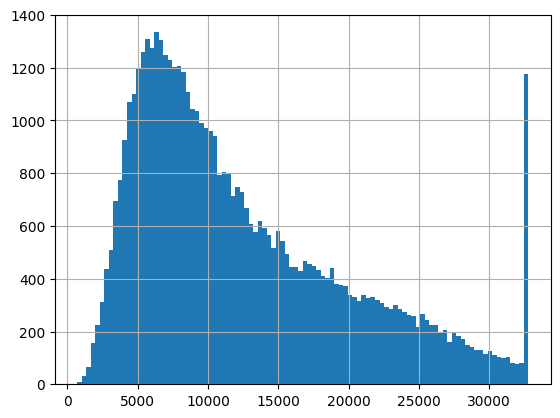

In [47]:
import pandas as pd
import numpy as np
import datetime

# 1. 读取刚刚生成的 CSV 文件 (请确认文件名与你保存的一致)
# 如果文件名有变动，请在这里修改
csv_filename = "omni_math_difficulty_analysis_20260407_023234.csv"
df = pd.read_csv(csv_filename)

# 2. 将 Difficulty 转换为整数，作为大组 (例如 1.5 -> 1, 9.5 -> 9)
df['Difficulty Group'] = df['Difficulty'].apply(lambda x: int(float(x)))

# 3. 定义一个函数来正确合并聚合数据（处理加权平均和方差）
def merge_difficulty_groups(g):
    total_q = g['Question Count'].sum()
    
    # 计算加权平均的正确率和长度
    pass_1 = (g['Pass@1 (%)'] * g['Question Count']).sum() / total_q
    pass_8 = (g['Pass@8 (%)'] * g['Question Count']).sum() / total_q
    mean_len = (g['Length Mean'] * g['Question Count']).sum() / total_q
    
    # 计算合并后的总方差：E[X^2] - (E[X])^2
    # E[X^2] = 组内方差 + 组内均值的平方
    sum_sq = (g['Question Count'] * (g['Length Variance'] + g['Length Mean']**2)).sum()
    var_len = (sum_sq / total_q) - (mean_len**2)
    
    return pd.Series({
        'Question Count': total_q,
        'Pass@1 (%)': pass_1,
        'Pass@8 (%)': pass_8,
        'Length Mean': mean_len,
        'Length Variance': var_len
    })

# 4. 执行分组聚合
grouped_df = df.groupby(['Model', 'Difficulty Group']).apply(merge_difficulty_groups).reset_index()

# 强制将 Question Count 转回整数
grouped_df['Question Count'] = grouped_df['Question Count'].astype(int)

# 5. 打印美化后的结果
print("\n" + "="*90)
print("🏆 Omni-Math 难度粗粒度合并评测报告 (1-9级)")
print("="*90)

print(grouped_df.to_string(formatters={
    'Pass@1 (%)': '{:.2f}'.format,
    'Pass@8 (%)': '{:.2f}'.format,
    'Length Mean': '{:.1f}'.format,
    'Length Variance': '{:.1f}'.format
}, index=False))

# 6. 保存新的 CSV
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
save_filename = f"omni_math_difficulty_merged_{timestamp}.csv"
grouped_df.to_csv(save_filename, index=False, encoding='utf-8-sig')

print("-" * 90)
print(f"💾 合并后的粗粒度报告已保存至: {save_filename}")


🏆 Omni-Math 难度粗粒度合并评测报告 (1-9级)
                        Model  Difficulty Group  Question Count Pass@1 (%) Pass@8 (%) Length Mean Length Variance
deepseek-r1-distill-qwen-1.5b                 1             335      69.78      79.70      2694.7      11821832.3
deepseek-r1-distill-qwen-1.5b                 2             343      59.48      75.51      6914.9      44113827.2
deepseek-r1-distill-qwen-1.5b                 3             224      49.78      67.41      9943.2      53320383.0
deepseek-r1-distill-qwen-1.5b                 4             957      29.15      51.20     13313.8      55491155.7
deepseek-r1-distill-qwen-1.5b                 5            1280      21.85      39.53     14324.3      54020926.6
deepseek-r1-distill-qwen-1.5b                 6             373      12.84      30.03     15228.0      44932575.2
deepseek-r1-distill-qwen-1.5b                 7             464      10.45      20.47     15095.8      37351540.8
deepseek-r1-distill-qwen-1.5b                 8         

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
# 1. 导入你刚刚写的独立模块
from vllm_workers import VLLMDPWorkerPool

# MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
# MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
# MODEL_NAME = "Qwen/Qwen3-0.6B"
MODEL_NAME = "Qwen/Qwen3-1.7B"

TOKENIZER = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tok = TOKENIZER
tokenizer = TOKENIZER
tokenizer.padding_side = 'left'

# 初始化离线 vLLM 集群 (分别放在 GPU 1, 2, 3)
vllm_engine = VLLMDPWorkerPool(model_name=MODEL_NAME, gpu_ids=[1, 2, 3])

# 初始化你的主优化模型 (放在 GPU 0)
# 注意：跑这段代码的环境里不能设置全局的 CUDA_VISIBLE_DEVICES="0"，否则子进程看不到其他卡
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, trust_remote_code=True, dtype=torch.bfloat16).cuda(0)

from time import sleep
sleep(25)  # 等待 vLLM Worker 完全启动

In [ ]:
import os
import json
import math
import argparse
import traceback
import torch
import torch.nn.functional as F
import pandas as pd
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer
import wandb
from rouge_score import rouge_scorer

# =========================================================================
# [0] 依赖引入 (确保 math_utils 和 vllm_workers 可用)
# =========================================================================
from math_utils import is_correct_v3, last_boxed_only_string, remove_boxed, is_equiv
from vllm_workers import VLLMDPWorkerPool

# =========================================================================
# [1] 数据集与内存优化管理
# =========================================================================
class MathWrongDataset(Dataset):
    def __init__(self, raw_samples, tok):
        self.flat_data = []
        index = 0
        for sample_idx, sample in enumerate(raw_samples):
            messages = [{"role": "user", "content": sample['problem']}]
            question_text = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            gt_text = sample['gold_answer'].strip() + "}"
            
            for response_idx, wrong_response in enumerate(sample['complete_wrong_responses']):
                uid = f"sample{sample_idx}_resp{response_idx}"
                try:
                    parts = wrong_response.split("</think>")
                    thinking_text = parts[0]
                    after_thinking_text = parts[1] if len(parts) > 1 else ""
                    assert "\\boxed{" in after_thinking_text, f"[{uid}] 缺少 boxed 结果"
                    
                    pred_box_text = last_boxed_only_string(after_thinking_text) 
                    connector_text = after_thinking_text.split(pred_box_text)[0] + "\\boxed{"
                    pred_text = remove_boxed(pred_box_text) + "}"
                    
                    self.flat_data.append({
                        "uid": uid, "question_text": question_text,
                        "answer_text": wrong_response, "thinking_text": thinking_text,
                        "connector_text": connector_text, "pred_text": pred_text,
                        "gt_text": gt_text
                    })
                    index += 1
                except Exception:
                    pass

    def __len__(self): return len(self.flat_data)
    def __getitem__(self, idx): return self.flat_data[idx]

def build_math_wrong_dataset(file_path: str, tok: AutoTokenizer) -> MathWrongDataset:
    print(f"📄 读取文件: {file_path}")
    results = [json.loads(line) for line in open(file_path, 'r', encoding='utf-8')]
    
    new_wrong_data = []
    for item in tqdm(results, desc="Processing Data"):
        gold_answer = item.get('answer', '')
        responses = item.get('responses', [])
        if not any(is_correct_v3(p, gold_answer) for p in responses):
            complete_but_wrong_responses = [
                res for res in responses 
                if last_boxed_only_string(res) and remove_boxed(last_boxed_only_string(res)) not in gold_answer.strip()
            ]
            if complete_but_wrong_responses:
                new_wrong_data.append({
                    "problem": item.get('problem', ''), "gold_answer": gold_answer,
                    "complete_wrong_responses": complete_but_wrong_responses
                })
    return MathWrongDataset(new_wrong_data, tok)

# =========================================================================
# [2] 优化器定义
# =========================================================================
class FrankWolfeOptimizer:
    def __init__(self, vocab_embeddings):
        self.W_emb = vocab_embeddings

    def step(self, latent_tensor, gamma):
        if latent_tensor.grad is None: return
        grad = latent_tensor.grad.detach()
        with torch.no_grad():
            scores = torch.matmul(grad, self.W_emb.T)
            best_vocab_indices = torch.argmin(scores, dim=-1)
            latent_tensor.copy_((1 - gamma) * latent_tensor + gamma * self.W_emb[best_vocab_indices])
            latent_tensor.grad.zero_()

# =========================================================================
# [3] 主流程 (Epoch-based 架构)
# =========================================================================
def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--model_name", type=str, default="deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B")
    parser.add_argument("--file_path", type=str, required=True)
    parser.add_argument("--vllm_gpus", type=int, nargs='+', default=[1, 2, 3])
    parser.add_argument("--batch_size", type=int, default=2)
    parser.add_argument("--chunk_size", type=int, default=1024)
    parser.add_argument("--learning_rate", type=float, default=2e-3)
    parser.add_argument("--steps", type=int, default=40, help="实际上是 Epoch 数量")
    parser.add_argument("--kl_weight", type=float, default=0.0)
    parser.add_argument("--eval_every", type=int, default=5)
    parser.add_argument("--eval_k", type=int, default=32)
    parser.add_argument("--mask_strategy", type=str, default="top_k_entropy", choices=["top_k_entropy", "first_k"])
    parser.add_argument("--mask_max_k", type=int, default=32768)
    parser.add_argument("--grad_direction", type=str, default="positive", choices=["positive", "negative"])
    parser.add_argument("--optimizer", type=str, default="adam", choices=["adam", "frank_wolfe"])
    parser.add_argument("--conn_type", type=str, default="fast", choices=["fast", "original"])
    parser.add_argument("--reg_type", type=str, default="kl", choices=["kl", "lm_prior"])
    parser.add_argument("--early_stop", action="store_true")
    parser.add_argument("--early_stop_threshold", type=float, default=1e-3)
    return parser.parse_args()

def main():
    args = parse_args()
    wandb.init(project="L-GRPO-Math500", name=f"opt_v2_{args.optimizer}_{args.reg_type}", config=vars(args))
    wandb.define_metric("global_step")
    wandb.define_metric("train/*", step_metric="global_step")
    wandb.define_metric("eval/*", step_metric="global_step")

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Loading Main Model with Flash Attention 2 to {device}...")
    tokenizer = AutoTokenizer.from_pretrained(args.model_name, trust_remote_code=True)
    tokenizer.padding_side = 'left'
    
    model = AutoModelForCausalLM.from_pretrained(
        args.model_name, trust_remote_code=True, 
        dtype=torch.bfloat16, attn_implementation="flash_attention_2"
    ).to(device)
    model.requires_grad_(False)
    model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False}) 
    
    vllm_engine = VLLMDPWorkerPool(model_name=args.model_name, gpu_ids=args.vllm_gpus)
    
    def get_embeds(text):
        ids = tokenizer.encode(text, return_tensors="pt", add_special_tokens=False).to(device)
        return model.get_input_embeddings()(ids).detach(), ids

    embeds_end_think, ids_end_think = get_embeds("</think>")
    embeds_fast_conn, ids_fast_conn = get_embeds("The final answer is \n&&\n\\boxed{")
    all_embeddings = model.get_input_embeddings().weight.detach()
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

    wrong_dataset = build_math_wrong_dataset(args.file_path, tokenizer)
    
    # 临时测试：截取前 24 个样本跑 Demo
    raw_data = wrong_dataset.flat_data[:24]

    # ==================================================
    # Phase 1: 构建 CPU 静态缓存 & GPU 活跃潜变量注册表
    # ==================================================
    print("⚙️ Preparing Static Data (CPU) & Latents (GPU)...")
    static_data_cpu = {}
    global_latents = torch.nn.ParameterDict()
    active_uids = []
    
    global_history = {
        d['uid']: {"uid": d['uid'], "problem": d['question_text'], "gt_text": d['gt_text'], "steps": []} 
        for d in raw_data
    }

    for d in tqdm(raw_data, desc="Pre-computing"):
        uid = d['uid']
        active_uids.append(uid)
        
        embeds_q, ids_q = get_embeds(d['question_text'])
        embeds_conn, ids_conn = get_embeds(d['connector_text']) if args.conn_type == "original" else (embeds_fast_conn, ids_fast_conn)
        embeds_gt, ids_gt = get_embeds(d['gt_text'])
        embeds_pred, ids_pred = get_embeds(d['pred_text'])
        embeds_think, ids_think = get_embeds(d['thinking_text'])
        
        curr_think = torch.nn.Parameter(embeds_think.detach().clone())
        global_latents[uid] = curr_think
        
        with torch.no_grad():
            orig_full = torch.cat([embeds_q, embeds_think, embeds_end_think, embeds_conn], dim=1)
            orig_out = model(inputs_embeds=orig_full)
            think_start_idx = ids_q.shape[1] - 1
            think_end_idx = think_start_idx + ids_think.shape[1]
            orig_probs = F.softmax(orig_out.logits[:, think_start_idx:think_end_idx, :], dim=-1)
            
            if args.mask_strategy == "top_k_entropy":
                entropy = -torch.sum(orig_probs * torch.log(orig_probs + 1e-10), dim=-1)
                mask = torch.zeros_like(entropy, dtype=torch.float32)
                mask.scatter_(1, torch.topk(entropy, k=min(args.mask_max_k, entropy.shape[1]), dim=1).indices, 1.0)
            else:
                mask = torch.zeros_like(ids_think, dtype=torch.float32)
                mask[:, :args.mask_max_k] = 1.0
                
            topk_probs, topk_indices = torch.topk(orig_probs, k=100, dim=-1)
            
            static_data_cpu[uid] = {
                "ids_q": ids_q.cpu(), "embeds_q": embeds_q.cpu(),
                "ids_conn": ids_conn.cpu(), "embeds_conn": embeds_conn.cpu(),
                "ids_gt": ids_gt.cpu(), "embeds_gt": embeds_gt.cpu(),
                "ids_pred": ids_pred.cpu(), "embeds_pred": embeds_pred.cpu(),
                "ids_think": ids_think.cpu(),
                "grad_mask": mask.unsqueeze(-1).cpu(),
                "topk_probs": topk_probs.cpu(), "topk_indices": topk_indices.cpu(),
                "thinking_text": d['thinking_text']
            }
            del orig_full, orig_out, orig_probs
            
    torch.cuda.empty_cache()
    
    if args.optimizer == "adam":
        optimizer = torch.optim.Adam(global_latents.values(), lr=args.learning_rate)
    else:
        optimizer = FrankWolfeOptimizer(all_embeddings)

    history_file = open("optimization_history_v2.jsonl", "a", encoding="utf-8")

    # ==================================================
    # Phase 2: 外层循环 (Global Steps / Epochs)
    # ==================================================
    for step in range(args.steps):
        if not active_uids:
            print("🎉 所有样本均已触发 Early Stop，训练提前结束！")
            break
            
        print(f"\n==============================================")
        print(f"🔄 Global Step {step+1}/{args.steps} | Active Samples: {len(active_uids)}")
        print(f"==============================================")
        
        progress = step / max(1, args.steps - 1)
        cosine_factor = 0.5 * (1.0 + math.cos(math.pi * progress))
        current_lr = (args.learning_rate * 0.1) + (args.learning_rate * 0.9) * cosine_factor
        
        if args.optimizer == "adam":
            for pg in optimizer.param_groups: pg['lr'] = current_lr
        
        step_metrics = {uid: {} for uid in active_uids}
        
        # 记录 Epoch 全局累计 Loss
        epoch_gt_loss_sum = 0.0
        epoch_kl_loss_sum = 0.0
        epoch_lm_loss_sum = 0.0
        epoch_total_loss_sum = 0.0
        
        # --------------------------------------------------
        # 2.1 内层循环: 动态 Batch 迭代优化
        # --------------------------------------------------
        import random
        random.shuffle(active_uids) 
        
        mini_batches = [active_uids[i:i + args.batch_size] for i in range(0, len(active_uids), args.batch_size)]
        pbar = tqdm(mini_batches, desc=f"Step {step+1} Optimizing")
        
        for batch_uids in pbar:
            if args.optimizer == "adam": optimizer.zero_grad(set_to_none=True)
            else:
                for uid in batch_uids:
                    if global_latents[uid].grad is not None: global_latents[uid].grad.zero_()

            curr_think_list, curr_mask_list = [], []
            embeds_q_list, embeds_conn_list, embeds_gt_list, embeds_pred_list = [], [], [], []
            ids_q_list, ids_think_list, ids_conn_list, ids_gt_list, ids_pred_list = [], [], [], [], []
            
            for uid in batch_uids:
                curr_think_list.append(global_latents[uid])
                sd = static_data_cpu[uid]
                
                curr_mask_list.append(sd["grad_mask"].to(device))
                embeds_q_list.append(sd["embeds_q"].to(device))
                embeds_conn_list.append(sd["embeds_conn"].to(device))
                embeds_gt_list.append(sd["embeds_gt"].to(device))
                embeds_pred_list.append(sd["embeds_pred"].to(device))
                
                ids_q_list.append(sd["ids_q"].to(device))
                ids_think_list.append(sd["ids_think"].to(device))
                ids_conn_list.append(sd["ids_conn"].to(device))
                ids_gt_list.append(sd["ids_gt"].to(device))
                ids_pred_list.append(sd["ids_pred"].to(device))

            full_embeds_list = []
            for i in range(len(batch_uids)):
                target_emb = embeds_gt_list[i] if args.grad_direction == "positive" else embeds_pred_list[i]
                full_embeds_list.append(torch.cat([embeds_q_list[i], curr_think_list[i].to(model.dtype), embeds_end_think, embeds_conn_list[i], target_emb], dim=1))

            max_len = max(emb.shape[1] for emb in full_embeds_list)
            attention_mask_list = []
            for i, emb in enumerate(full_embeds_list):
                if emb.shape[1] < max_len:
                    pad_emb = torch.zeros((emb.shape[0], max_len - emb.shape[1], emb.shape[2]), device=device, dtype=model.dtype)
                    full_embeds_list[i] = torch.cat([emb, pad_emb], dim=1)
                    attn = torch.zeros((emb.shape[0], max_len), device=device, dtype=torch.long)
                    attn[:, :emb.shape[1]] = 1
                    attention_mask_list.append(attn)
                else:
                    attention_mask_list.append(torch.ones((emb.shape[0], max_len), device=device, dtype=torch.long))
                    
            full_embeds_batch = torch.cat(full_embeds_list, dim=0)
            full_attention_mask = torch.cat(attention_mask_list, dim=0)

            last_hidden = model.model(inputs_embeds=full_embeds_batch, attention_mask=full_attention_mask).last_hidden_state

            all_gt_loss, all_kl_div_list, batch_logprobs = [], [], []
            for i, uid in enumerate(batch_uids):
                sd = static_data_cpu[uid]
                gt_pos = ids_q_list[i].shape[1] + ids_think_list[i].shape[1] + ids_end_think.shape[1] + ids_conn_list[i].shape[1] - 1
                target_ids = ids_gt_list[i] if args.grad_direction == "positive" else ids_pred_list[i]
                
                target_logits = model.lm_head(last_hidden[[i], gt_pos : gt_pos + target_ids.shape[1], :])
                gt_loss = F.cross_entropy(target_logits.view(-1, target_logits.size(-1)), target_ids.view(-1))
                if args.grad_direction == "negative": gt_loss = -gt_loss
                all_gt_loss.append(gt_loss)
                
                think_start = ids_q_list[i].shape[1] - 1
                think_end = think_start + ids_think_list[i].shape[1]
                curr_think_hidden = last_hidden[[i], think_start:think_end, :] 
                think_len = curr_think_hidden.shape[1]
                
                kl_sum, logprobs_sum = 0.0, 0.0
                orig_probs_topk = sd["topk_probs"].to(device)
                orig_indices_topk = sd["topk_indices"].to(device)
                
                curr_think_embeds = torch.cat([curr_think_list[i][:, 1:ids_think_list[i].shape[1], :], embeds_end_think], dim=1)
                target_ids_think = torch.cat([ids_think_list[i][:, 1:], ids_end_think], dim=1) 
                
                for c_start in range(0, think_len, args.chunk_size):
                    c_end = min(c_start + args.chunk_size, think_len)
                    h_chunk = curr_think_hidden[:, c_start:c_end, :]
                    logits_chunk = model.lm_head(h_chunk) 
                    lse_chunk = torch.logsumexp(logits_chunk, dim=-1, keepdim=True)
                    
                    orig_p_chunk = orig_probs_topk[:, c_start:c_end, :]
                    orig_idx_chunk = orig_indices_topk[:, c_start:c_end, :]
                    curr_log_probs_topk_chunk = torch.gather(logits_chunk, -1, orig_idx_chunk) - lse_chunk
                    kl_chunk = (orig_p_chunk * (torch.log(orig_p_chunk + 1e-10) - curr_log_probs_topk_chunk)).sum(dim=-1)
                    kl_sum += kl_chunk.sum() 
                    
                    embeds_chunk = curr_think_embeds[:, c_start:c_end, :]
                    target_ids_chunk = target_ids_think[:, c_start:c_end] 
                    orig_embeds_chunk = model.get_input_embeddings()(target_ids_chunk).detach()
                    
                    orig_norm = torch.norm(orig_embeds_chunk, p=2, dim=-1, keepdim=True)
                    curr_norm = torch.norm(embeds_chunk, p=2, dim=-1, keepdim=True)
                    scaled_embeds_chunk = embeds_chunk * (orig_norm / (curr_norm + 1e-8))
                    
                    score_0_chunk = (h_chunk * scaled_embeds_chunk).sum(dim=-1) 
                    mask = torch.zeros_like(logits_chunk, dtype=torch.bool)
                    mask.scatter_(2, target_ids_chunk.unsqueeze(-1), True)
                    
                    new_logits_chunk = torch.where(mask, score_0_chunk.unsqueeze(-1), logits_chunk)
                    logprobs_sum += (score_0_chunk - torch.logsumexp(new_logits_chunk, dim=-1)).sum()
                    
                    del h_chunk, logits_chunk, lse_chunk, orig_p_chunk, orig_idx_chunk
                    del curr_log_probs_topk_chunk, kl_chunk, embeds_chunk, target_ids_chunk
                    del orig_embeds_chunk, scaled_embeds_chunk, score_0_chunk, mask, new_logits_chunk
                    
                all_kl_div_list.append(kl_sum / think_len)
                batch_logprobs.append(logprobs_sum / think_len)
                
                step_metrics[uid] = {
                    "gt_loss": gt_loss.item(),
                    "kl_loss": (kl_sum / think_len).item(),
                    "lm_loss": -(logprobs_sum / think_len).item()
                }

            # Batch 级 Loss 聚合
            batch_gt_loss = torch.stack(all_gt_loss).mean()
            batch_kl_loss = torch.stack(all_kl_div_list).mean()
            batch_lm_prior_loss = -torch.stack(batch_logprobs).mean()
            
            reg_loss = batch_kl_loss if args.reg_type == "kl" else batch_lm_prior_loss
            total_loss = batch_gt_loss + args.kl_weight * reg_loss
            
            # 更新 Epoch 总 Loss (累加计算均值)
            batch_sample_count = len(batch_uids)
            epoch_gt_loss_sum += batch_gt_loss.item() * batch_sample_count
            epoch_kl_loss_sum += batch_kl_loss.item() * batch_sample_count
            epoch_lm_loss_sum += batch_lm_prior_loss.item() * batch_sample_count
            epoch_total_loss_sum += total_loss.item() * batch_sample_count
            
            # 丰富进度条内容
            pbar.set_postfix({
                "Total": f"{total_loss.item():.3f}", 
                "GT": f"{batch_gt_loss.item():.3f}",
                "KL": f"{batch_kl_loss.item():.3f}",
                "LM": f"{batch_lm_prior_loss.item():.3f}"
            })
            
            total_loss.backward()
            for mask, latent in zip(curr_mask_list, curr_think_list):
                latent.grad.mul_(mask.to(latent.dtype))
                
            if args.optimizer == "adam": optimizer.step()
            else:
                for latent, mask in zip(curr_think_list, curr_mask_list):
                    optimizer.step(latent, gamma=0.01 + 0.09 * cosine_factor)

            del full_embeds_batch, full_attention_mask, last_hidden
            torch.cuda.empty_cache()

        # --------------------------------------------------
        # 2.2 全局评测 (ROUGE-L, Acc, Wandb Logging)
        # --------------------------------------------------
        # 1. 记录 Epoch 级别各种平均 Loss 到 WandB
        wandb.log({
            "global_step": step,
            "train/epoch_total_loss": epoch_total_loss_sum / len(active_uids),
            "train/epoch_gt_loss": epoch_gt_loss_sum / len(active_uids),
            "train/epoch_kl_loss": epoch_kl_loss_sum / len(active_uids),
            "train/epoch_lm_loss": epoch_lm_loss_sum / len(active_uids),
            "train/lr": current_lr,
            "active_samples": len(active_uids)
        })

        if step % args.eval_every == 0 or step == args.steps - 1:
            total_pure_acc, total_forced_acc, total_fast_acc = 0.0, 0.0, 0.0
            total_rouge_l, total_change_ratio = 0.0, 0.0
            
            print(f"🚀 [Global Eval] 1/2 计算潜空间 Token 漂移度 (ROUGE-L & Change Ratio)...")
            for uid in active_uids:
                ct = global_latents[uid].to(all_embeddings.dtype).detach()
                sd = static_data_cpu[uid]
                
                target_flat = ct.squeeze(0)
                sim = torch.matmul(F.normalize(target_flat, dim=-1), F.normalize(all_embeddings, dim=-1).T)
                nearest_token_ids = torch.argmax(sim, dim=-1)
                
                orig_ids = sd["ids_think"].to(device).squeeze(0)
                changed_mask = (nearest_token_ids != orig_ids)
                change_ratio = changed_mask.float().mean().item()
                
                decoded_nearest_text = tokenizer.decode(nearest_token_ids).strip()
                original_thinking_clean = sd['thinking_text']
                rouge_l_f1 = scorer.score(original_thinking_clean[:10000], decoded_nearest_text[:10000])['rougeL'].fmeasure
                
                step_metrics[uid]['change_ratio'] = change_ratio
                step_metrics[uid]['rouge_L'] = rouge_l_f1
                
                total_change_ratio += change_ratio
                total_rouge_l += rouge_l_f1

            print(f"🚀 [Global Eval] 2/2 发送 {len(active_uids)} 个潜变量至 vLLM Worker Pool...")
            eval_pure_inputs, eval_forced_inputs, eval_fast_inputs = [], [], []
            for uid in active_uids:
                ct = global_latents[uid].to(all_embeddings.dtype).detach()
                sd = static_data_cpu[uid]
                embeds_q = sd["embeds_q"].to(device)
                embeds_conn = sd["embeds_conn"].to(device)
                
                eval_pure_inputs.append(torch.cat([embeds_q, ct, embeds_end_think], dim=1).squeeze(0))
                eval_forced_inputs.append(torch.cat([embeds_q, ct, embeds_end_think, embeds_conn], dim=1).squeeze(0))
                eval_fast_inputs.append(torch.cat([embeds_q, ct, embeds_end_think, embeds_fast_conn], dim=1).squeeze(0))

            modes = [('pure', eval_pure_inputs, 2048), ('forced', eval_forced_inputs, 128), ('fast', eval_fast_inputs, 128)]
            
            for mode, inputs_list, max_toks in modes:
                batch_outputs = vllm_engine.generate(inputs_list, {"max_tokens": max_toks, "temperature": 0.7, "n": args.eval_k, "skip_special_tokens": False})
                if not batch_outputs: continue
                
                for idx, uid in enumerate(active_uids):
                    gt_text = global_history[uid]['gt_text']
                    gt_token_len = len(tokenizer.encode(gt_text, add_special_tokens=False))
                    
                    correct_count = 0
                    for output_ids in batch_outputs[idx]:
                        if mode != 'pure': output_ids = output_ids[:gt_token_len]
                        gen_text = tokenizer.decode(output_ids, skip_special_tokens=True)
                        is_corr = False
                        
                        if mode == 'pure':
                            if is_correct_v3(gen_text, gt_text.replace("}", "")): is_corr = True
                        else:
                            ans = gen_text.replace("$", "").replace("}", "").strip()
                            if is_equiv(ans, gt_text.replace("}", "")): is_corr = True
                        
                        if is_corr: correct_count += 1
                            
                    acc = correct_count / args.eval_k
                    step_metrics[uid][f'{mode}_acc'] = acc
                    
                    if mode == 'pure': total_pure_acc += acc
                    elif mode == 'forced': total_forced_acc += acc
                    elif mode == 'fast': total_fast_acc += acc

            # 2. 完整记录评测平均值到终端与 WandB
            print(f"📊 [Eval Results] Pure Acc: {total_pure_acc/len(active_uids):.2%} | Forced Acc: {total_forced_acc/len(active_uids):.2%} | Fast Acc: {total_fast_acc/len(active_uids):.2%}")
            print(f"📉 [Latent Drift] ROUGE-L: {total_rouge_l/len(active_uids):.4f} | Change Ratio: {total_change_ratio/len(active_uids):.2%}")
            
            wandb.log({
                "global_step": step,
                "eval/avg_pure_acc": total_pure_acc / len(active_uids),
                "eval/avg_forced_acc": total_forced_acc / len(active_uids),
                "eval/avg_fast_acc": total_fast_acc / len(active_uids),
                "eval/avg_rouge_L": total_rouge_l / len(active_uids),
                "eval/avg_change_ratio": total_change_ratio / len(active_uids)
            })

        # --------------------------------------------------
        # 2.3 Early Stop 动态修剪
        # --------------------------------------------------
        next_active_uids = []
        for uid in active_uids:
            global_history[uid]["steps"].append({"step": step, "metrics": step_metrics[uid]})
            
            gt_loss = step_metrics[uid]["gt_loss"]
            if args.early_stop and gt_loss < args.early_stop_threshold:
                print(f"  🔪 [修剪] 样本 {uid} 达标 (Loss: {gt_loss:.4f})，已写出并移出训练队列。")
                history_file.write(json.dumps(global_history[uid], ensure_ascii=False) + "\n")
                history_file.flush()
                del static_data_cpu[uid] 
            else:
                next_active_uids.append(uid)
                
        active_uids = next_active_uids

    if active_uids:
        print(f"\n📁 写入剩余 {len(active_uids)} 个未早停的样本历史...")
        for uid in active_uids:
            history_file.write(json.dumps(global_history[uid], ensure_ascii=False) + "\n")
        history_file.flush()
        
    history_file.close()
    wandb.finish()

if __name__ == "__main__":
    main()

In [ ]:
# data
import pandas as pd
import json
from transformers import AutoTokenizer
from tqdm.auto import tqdm
tqdm.pandas()
import re

# MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
# MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
# MODEL_NAME = "Qwen/Qwen3-0.6B"
MODEL_NAME = "Qwen/Qwen3-1.7B"

tok = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer = tok
# 3. 读取数据
file_path = "/workspace/yiqiuguo/lsrl/gen_results/qwen3-1.7b_dapo_math_14k_en_openinstruct_rollout8_run20260409_n098_node0256.jsonl"
results = []
with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        results.append(json.loads(line))

# 4. 核心评估逻辑
eval_data = []
for item in results:
    gold_answer = item.get('ground_truth', '')
    responses = item.get('responses', [])
    
    # 提取这 8 个回复的预测值
    preds = [res for res in responses]
    # 判断每一个是否正确 (True/False 列表)
    correctness = [is_correct_v3(p, gold_answer) for p in preds]
    eval_data.append({
        "problem": item.get('problem', '')[:50] + "...",
        "gold": gold_answer,
        "preds": preds,
        "correctness": correctness,
        "num_correct": sum(correctness),
        "any_correct": any(correctness) # Pass@8 的基础
    })

eval_df = pd.DataFrame(eval_data)

# 5. 计算指标
total_questions = len(eval_df)
# Pass@1: 所有生成的回复中正确的比例 (Total_Correct / (Total_Questions * 8))
pass_at_1 = eval_df['num_correct'].sum() / (total_questions * 8)
# Pass@8: 至少有一个回复正确的题目比例
pass_at_8 = eval_df['any_correct'].mean()

# --- 打印结果 ---
print("-" * 30)
print(f"📊 评测报告 (基于 {total_questions} 道题)")
print("-" * 30)
print(f"✅ Pass @ 1 (平均准确率): {pass_at_1:.2%}")
print(f"🚀 Pass @ 8 (至少对一个): {pass_at_8:.2%}")
print("-" * 30)


# 展示部分细节：哪些是对的，哪些是错的
display_cols = ['gold', 'num_correct', 'any_correct', 'correctness']
print("\n前 5 条数据详情 (correctness 列表展示了 8 个回复的对错):")
eval_df[display_cols].head()

# 1. 筛选 8 次尝试全部错误的数据
# conditions: any_correct 为 False
wrong_df = eval_df[eval_df['any_correct'] == False].copy()

# 2. 将这些错误数据收集到一个 list 中
# 包含：原始问题、标准答案、以及模型那 8 个全错的回复（方便分析错在哪）
wrong_data = []

for idx, row in wrong_df.iterrows():
    # 重新从原始结果中获取完整的 responses（之前 eval_df 为了展示只存了前50个字符）
    # 假设你的原始数据在 results 列表里，索引是一致的
    original_item = results[idx] 
    item = original_item.copy()  # 避免修改原始数据
    item.update({
        "gold_answer": original_item.get('ground_truth'),
        "bad_responses": original_item.get('responses'), # 这 8 个都是错的
        "extracted_preds": row['preds'],                  # 对应提取出的错误答案
    })
    wrong_data.append(item)

# 3. 打印统计信息
print(f"统计结果：")
print(f"总题目数: {len(results)}")
print(f"全错题目数 (Wrong Data): {len(wrong_data)}")
print(f"模型全错率: {len(wrong_data) / len(results):.2%}")

# 4. 展示一个典型“翻车”案例
if wrong_data:
    print("\n--- 典型错误案例展示 ---")
    example = wrong_data[0]
    print(f"【题目】: {example['prompt']}")
    print(f"【标准答案】: {example['gold_answer']}")
    # print(f"【模型第一个错误尝试提取值】: {example['extracted_preds'][0]}")
    
    # print('【bad_responses】: ', example['bad_responses'][0])
    extracted_box = last_boxed_only_string(example['bad_responses'][0])
    model_answer = remove_boxed(extracted_box)
    print('【model_answer】: ', model_answer)
    sp = example['gold_answer'].split("\\text{")
    print(f"【remove_right_units split gold】: {sp}")
    print(f"【remove_right_units gold】: {remove_right_units(example['gold_answer'])}")
    print(f"【strip gold】: {strip_string(example['gold_answer'])}")
    print('【is_equivalent】: ', is_equiv(model_answer, example['gold_answer']))
    
new_wrong_data = []

# 遍历之前判断为“全错”的数据
# 假设 wrong_data_final 是通过 is_correct_v3 判定为 any_correct == False 的原始数据列表
for item in wrong_data:
    problem = item.get('problem')
    gold = item.get('gold_answer')
    responses = item.get('bad_responses', [])
    
    # 筛选出那些真正输出了 \boxed 的回复
    complete_but_wrong_responses = []
    
    # print('gold: ', gold)
    for res in responses:
        # 使用你提供的官方函数检测是否有完整的 boxed
        boxed_str = last_boxed_only_string(res)
        
        if boxed_str is not None and remove_boxed(boxed_str) not in gold.strip():
            # print('boxed_str: ', boxed_str)
            # 既然在 wrong_data_final 里，说明这个 res 肯定是不对的
            # 我们只需要确认它“写完了”
            complete_but_wrong_responses.append(res)
    
    # 如果这个题目中，至少有一个回复是“完整写完但写错”的，我们就记录下来
    if len(complete_but_wrong_responses) > 0:
        new_entry = item.copy()
        # 
        new_entry['complete_wrong_responses'] = complete_but_wrong_responses
        new_wrong_data.append(new_entry)

# --- 打印分析结果 ---
print(f"📊 过滤结果:")
print(f"原本全错的题目数: {len(wrong_data)}")
print(f"其中包含完整输出的‘硬核’错误题目数 (new_wrong_data): {len(new_wrong_data)}")

# 展示一个
if new_wrong_data:
    example = new_wrong_data[0]
    print("\n--- 完整输出但错误的案例 ---")
    print(f"题目: {example['prompt']}")
    # print(f"模型的完整错误回复: {example['complete_wrong_responses'][0]}")
    print(f"标准答案: {example['gold_answer']}")
    print(f"模型给出的错误结论: {remove_boxed(last_boxed_only_string(example['complete_wrong_responses'][0]))}")




------------------------------
📊 评测报告 (基于 6553 道题)
------------------------------
✅ Pass @ 1 (平均准确率): 71.20%
🚀 Pass @ 8 (至少对一个): 88.71%
------------------------------

前 5 条数据详情 (correctness 列表展示了 8 个回复的对错):
统计结果：
总题目数: 6553
全错题目数 (Wrong Data): 740
模型全错率: 11.29%

--- 典型错误案例展示 ---
【题目】: In triangle $ABC$, $\sin \angle A = \frac{4}{5}$ and $\angle A < 90^\circ$. Let $D$ be a point outside triangle $ABC$ such that $\angle BAD = \angle DAC$ and $\angle BDC = 90^\circ$. Suppose that $AD = 1$ and that $\frac{BD}{CD} = \frac{3}{2}$. If $AB + AC$ can be expressed in the form $\frac{a\sqrt{b}}{c}$ where $a, b, c$ are pairwise relatively prime integers, find $a + b + c$.
【标准答案】: 34
【model_answer】:  14
【remove_right_units split gold】: ['34']
【remove_right_units gold】: 34
【strip gold】: 34
【is_equivalent】:  False
📊 过滤结果:
原本全错的题目数: 740
其中包含完整输出的‘硬核’错误题目数 (new_wrong_data): 731

--- 完整输出但错误的案例 ---
题目: In triangle $ABC$, $\sin \angle A = \frac{4}{5}$ and $\angle A < 90^\circ$. Let $D$ be a point outsid

In [16]:
import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM, AutoTokenizer
from torch.optim import Adam

# 1. 加载模型与分词器 (transformers 格式)
model_name = MODEL_NAME
tok = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

# 2. 准备 Wrong Data 中的一条数据 (示例)
# 假设你的 wrong_data 结构中已经有了成功的 think 路径但答案错了，或者你想优化这段 think
from rouge_score import rouge_scorer
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)


import torch
from torch.utils.data import Dataset, DataLoader

class MathWrongDataset(Dataset):
    def __init__(self, raw_samples, tok):
        """
        raw_samples: 原始的样本列表，例如 new_wrong_data
        tok: tokenizer
        """
        self.tok = tok
        self.flat_data = []
        
        index = 0
        # 展平数据：1 个 sample -> 8 个独立的数据点
        for sample_idx, sample in enumerate(raw_samples):
            question_text = apply_chat_template(tok, sample['q'])
            gt_text = sample['gold_answer'].strip() + "}"
            
            # 遍历所有的 wrong responses (假设有8个)
            for response_idx, wrong_response in enumerate(sample['complete_wrong_responses']):
                # 生成唯一标识符：原始样本ID_回答ID
                uid = f"sample{sample_idx}_resp{response_idx}"
                
                try:
                    thinking_text = wrong_response.split("</think>")[0]
                    after_thinking_text = wrong_response.split("</think>")[1]
                    
                    assert "\\boxed{" in after_thinking_text, f"[{uid}] 缺少 boxed 结果"
                    
                    # 假设你已经定义了这两个函数
                    pred_box_text = last_boxed_only_string(after_thinking_text) 
                    connector_text = after_thinking_text.split(pred_box_text)[0] + "\\boxed{"
                    pred_text = remove_boxed(pred_box_text) + "}"
                    
                    self.flat_data.append({
                        "index": index,
                        "uid": uid,
                        "question_text": question_text,
                        "answer_text": wrong_response,
                        "thinking_text": thinking_text,
                        "connector_text": connector_text,
                        "pred_text": pred_text,
                        "gt_text": gt_text,
                        "sample_idx": sample_idx # 用于后续聚合统计
                    })
                    index += 1
                except Exception as e:
                    # 获取完整的堆栈追踪字符串
                    import traceback
                    error_details = traceback.format_exc()
                    # print(f"Skipping {uid} due to parsing error:\n{error_details}")
    def __len__(self):
        return len(self.flat_data)

    def __getitem__(self, idx):
        return self.flat_data[idx]


dst = MathWrongDataset(new_wrong_data, tok)
print('dst: ', len(dst))

dst:  5267


In [ ]:
all_wrong_length = tok([d['question_text']+d['answer_text'] for d in dst], return_length=True)['length']

In [18]:
sum(all_wrong_length) 

95610504


In [19]:
all_think_length = tok([d['thinking_text'] for d in dst], return_length=True)['length']

In [ ]:
print(sum(all_think_length))

90069350


In [22]:
all_conn_length = tok([d['connector_text'] for d in dst], return_length=True)['length']

In [23]:
print(sum(all_conn_length))

4818048


In [ ]:
sum(all_think_length)*2*2048 / 1024 / 1024 / 1024

343.5873031616211

: 

In [ ]:
# run
# 假设配置字典
# ==========================================
# 初始化 Wandb (请确保你已经 wandb login)
# ==========================================
import wandb
import torch.nn.functional as F


run = wandb.init(
    project="L-GRPO-Math500",
    name="batch_opt_adam_lm_prior",
    config={
        "learning_rate": 2e-3,
        "steps": 40,
        "kl_weight": 0.0,
        "eval_every": 5,
        "eval_k": 32,
        "mask_strategy": "top_k_entropy",
        "mask_max_k": 32768,
        "grad_direction": "positive",
        "optimizer": "adam",
        "conn_type": "fast",
        "reg_type": "kl",
        "batch_size": 1,
        "early_stop": True,  # <--- 【新增】
        "early_stop_threshold": 1e-3  # <--- 【新增】
    }
)
config = wandb.config

# ==========================================
# 【新增】：告诉 WandB 使用 local_step 作为所有训练和评测指标的横坐标
# ==========================================
wandb.define_metric("local_step")
wandb.define_metric("train/*", step_metric="local_step")
wandb.define_metric("eval/*", step_metric="local_step")

# 1. 构造 DataLoader
real_bad_sample_idxs=[0,3,4,8,10,11,13,14,17,21,22,23]
real_wrong_data = [new_wrong_data[i] for i in real_bad_sample_idxs] 
dst = MathWrongDataset(real_wrong_data[4:5], tok)
print('dst: ', len(dst))
dataloader = DataLoader(dst, batch_size=config.batch_size, shuffle=False)

# 【关键修复】：冻结模型所有底层权重，阻止激活值缓存雪崩
model.requires_grad_(False)
model.gradient_checkpointing_enable()

# 2. 获取各部分 Embeddings (假设变量 question_text, thinking_text 等已定义)
def get_embeds(text):
    ids = tok.encode(text, return_tensors="pt", add_special_tokens=False).to(model.device)
    return model.get_input_embeddings()(ids).detach(), ids

embeds_end_think, ids_end_think = get_embeds("</think>")
fast_conn_text = "The final answer is \n&&\n\\boxed{" # 这个是我们在优化过程中用来快速验证的连接词，后面直接接答案
embeds_fast_conn, ids_fast_conn = get_embeds(fast_conn_text)


all_embeddings = model.get_input_embeddings().weight.detach()
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

grad_mask_list = []

# 仅在 config.reg_type == "kl" 时才用到，用于存储稀疏概率分布
orig_think_topk_probs_list = []
orig_think_topk_indices_list = []

from tqdm.auto import tqdm
import gc

for d in tqdm(dst, total=len(dst), desc="Preparing Latents & Masks"):
    embeds_q, ids_q = get_embeds(d['question_text'])
    embeds_conn, ids_conn = get_embeds(d['connector_text'])
    embeds_gt, ids_gt = get_embeds(d['gt_text'])
    embeds_think, ids_think = get_embeds(d['thinking_text'])
    
    # 2. 动态计算 Mask 或 压缩版的 KL 目标 (即算即抛)
    # 2. 动态计算 Mask 及 压缩版的 KL 目标
    with torch.no_grad():
        if config.mask_strategy == "first_k":
            mask = torch.zeros_like(ids_think, dtype=torch.float32)
            mask[:, :config.mask_max_k] = 1.0
            grad_mask_list.append(mask.unsqueeze(-1).cpu())
            
        # 【修改】：因为现在不论如何都要监控 KL loss，所以必须强制跑一次前向传播
        orig_full = torch.cat([embeds_q, embeds_think, embeds_end_think, embeds_conn], dim=1)
        orig_out = model(inputs_embeds=orig_full)
        
        think_start_idx = ids_q.shape[1] - 1
        think_end_idx = think_start_idx + ids_think.shape[1]
        orig_logits = orig_out.logits[:, think_start_idx : think_end_idx, :]
        orig_probs = F.softmax(orig_logits, dim=-1)
        
        if config.mask_strategy == "top_k_entropy":
            entropy = -torch.sum(orig_probs * torch.log(orig_probs + 1e-10), dim=-1)
            mask = torch.zeros_like(entropy, dtype=torch.float32)
            
            topk_k = min(config.mask_max_k, entropy.shape[1])
            high_entropy_indices = torch.topk(entropy, k=topk_k, dim=1).indices
            mask.scatter_(1, high_entropy_indices, 1.0)
            grad_mask_list.append(mask.unsqueeze(-1).cpu())
        
        # 【修改】：无条件提取并保存 Top-100 概率，供之后监控 KL 使用
        topk_probs, topk_indices = torch.topk(orig_probs, k=100, dim=-1)
        orig_think_topk_probs_list.append(topk_probs.cpu())
        orig_think_topk_indices_list.append(topk_indices.cpu())
        
        del orig_full, orig_out, orig_logits, orig_probs
    torch.cuda.empty_cache()


import json
import os

# 打开结构化日志文件，追加模式
history_file = open("optimization_history.jsonl", "w", encoding="utf-8")

for batch_idx, batch in enumerate(dataloader):
    print(f"\n=== Optimizing Batch {batch_idx+1}/{len(dataloader)} ===")
    indexs = batch['index']
    uids = batch['uid'] # 我们需要用它做样本级的追踪
    
    # 【新增】：为当前 Batch 的每个样本初始化 History 追踪结构
    batch_history = {
        uid: {
            "uid": uid,
            "sample_index": batch['sample_idx'][i].item(), # 记录源数据 index
            "problem": batch['question_text'][i],          # 记录原问题
            "gold_answer": batch['gt_text'][i],            # 记录标准答案
            "steps": []                                    # 用于存放每个 step 的字典
        } for i, uid in enumerate(uids)
    }
    
    # ==========================================
    # 1. 静态数据准备区 (在 step 外部做，提速百倍)
    # ==========================================
    curr_think_list = []
    curr_mask_list = []
    
    ids_q_list, ids_think_list, ids_conn_list = [], [], []
    ids_gt_list, ids_pred_list = [], []
    embeds_q_list, embeds_conn_list, embeds_gt_list, embeds_pred_list = [], [], [], []

    for i, index in enumerate(indexs):
        embeds_q, ids_q = get_embeds(batch['question_text'][i])
        embeds_think, ids_think = get_embeds(batch['thinking_text'][i])
        
        # 动态创建当前 batch 需要优化的 Latent
        curr_think = embeds_think.detach().clone()
        curr_think.requires_grad = True
        curr_think_list.append(curr_think)
        
        # 获取预先算好的 Mask
        if config.mask_strategy != "first_k":
            curr_mask_list.append(grad_mask_list[index].to(model.device))
        else:
            mask = torch.zeros_like(ids_think, dtype=torch.float32)
            mask[:, :config.mask_max_k] = 1.0
            curr_mask_list.append(mask.unsqueeze(-1).to(model.device))
        
        if config.conn_type == "original":
            embeds_conn, ids_conn = get_embeds(batch['connector_text'][i])
        elif config.conn_type == "fast":
            embeds_conn, ids_conn = embeds_fast_conn, ids_fast_conn
            
        embeds_gt, ids_gt = get_embeds(batch['gt_text'][i])
        embeds_pred, ids_pred = get_embeds(batch['pred_text'][i])

        # 缓存静态张量
        ids_q_list.append(ids_q)
        ids_think_list.append(ids_think)
        ids_conn_list.append(ids_conn)
        ids_gt_list.append(ids_gt)
        ids_pred_list.append(ids_pred)
        
        embeds_q_list.append(embeds_q)
        embeds_conn_list.append(embeds_conn)
        embeds_gt_list.append(embeds_gt)
        embeds_pred_list.append(embeds_pred)

    # ==========================================
    # 2. 初始化局部优化器 (只管当前这一个 Batch)
    # ==========================================
    if config.optimizer == "adam":
        from torch.optim import Adam
        optimizer = Adam(curr_think_list, lr=config.learning_rate)
    elif config.optimizer == "frank_wolfe":
        optimizer = FrankWolfeOptimizer(model.get_input_embeddings().weight.data)

    # ==========================================
    # 3. 核心 Step 循环 (猛烈敲打当前这几个 Latent)
    # ==========================================
    from tqdm.auto import tqdm
    import math
    
    # 【修改】：将 tqdm 赋给变量，方便后续更新显示信息
    step_pbar = tqdm(range(config.steps), desc=f"Batch {batch_idx+1} Opt")
    for step in step_pbar:
        # ==========================================
        # 【修改】：计算当前 Step 的 Cosine 衰减 Learning Rate (到 1/10)
        # ==========================================
        initial_lr = config.learning_rate
        final_lr = initial_lr * 0.1
        
        # 计算进度比例 (0.0 到 1.0)
        progress = step / max(1, config.steps - 1)
        
        # Cosine 衰减因子：利用 cos(pi * progress) 将值从 1.0 平滑过渡到 -1.0
        # 再通过 0.5 * (1 + x) 映射到 1.0 -> 0.0 的平滑曲线
        cosine_factor = 0.5 * (1.0 + math.cos(math.pi * progress))
        
        current_lr = final_lr + (initial_lr - final_lr) * cosine_factor
        
        # 如果你使用 frank_wolfe，对应的步长 gamma 也同步从 0.1 平滑衰减到 0.01
        current_gamma = 0.01 + (0.1 - 0.01) * cosine_factor
        
        if config.optimizer == "adam":
            # 动态更新 Adam 的学习率
            for param_group in optimizer.param_groups:
                param_group['lr'] = current_lr
            optimizer.zero_grad()
        elif config.optimizer == "frank_wolfe":
            for latent in curr_think_list:
                if latent.grad is not None:
                    latent.grad.zero_()

        # 拼接全序列 Embedding (使用局部变量 curr_think_list)
        full_embeds_list = []
        for i in range(len(indexs)):
            curr_think = curr_think_list[i].to(model.dtype)
            if config.grad_direction == "positive":
                full_embeds = torch.cat([embeds_q_list[i], curr_think, embeds_end_think, embeds_conn_list[i], embeds_gt_list[i]], dim=1)
            else:
                full_embeds = torch.cat([embeds_q_list[i], curr_think, embeds_end_think, embeds_conn_list[i], embeds_pred_list[i]], dim=1)
            full_embeds_list.append(full_embeds)

        # Padding 对齐
        max_len = max([emb.shape[1] for emb in full_embeds_list])
        attention_mask_list = []
        for i, emb in enumerate(full_embeds_list):
            if emb.shape[1] < max_len:
                pad_len = max_len - emb.shape[1]
                pad_emb = torch.randn((emb.shape[0], pad_len, emb.shape[2]), device=emb.device, dtype=model.dtype)
                full_embeds_list[i] = torch.cat([emb, pad_emb], dim=1)
                
                attention_mask = torch.zeros((emb.shape[0], max_len), device=emb.device, dtype=torch.long)
                attention_mask[:, :emb.shape[1]] = 1
                attention_mask_list.append(attention_mask)
            else:
                attention_mask_list.append(torch.ones((emb.shape[0], max_len), device=emb.device, dtype=torch.long))
                
        full_embeds_batch = torch.cat(full_embeds_list, dim=0)
        full_attention_mask = torch.cat(attention_mask_list, dim=0)

        # 前向传播 (因为 requires_grad=False，这里会非常省显存)
        last_hidden = model.model(inputs_embeds=full_embeds_batch, attention_mask=full_attention_mask).last_hidden_state
        # logits = model.lm_head(last_hidden)

        # ---------------- Loss 计算区域 ----------------
        all_gt_loss = []
        all_kl_div_list = []
        batch_logprobs = []
        
        # 我们额外需要一个列表存单样本最终的总 Loss，用来记入 log
        sample_total_losses = []
        
        # 【终极优化】：时间换空间的分块大小。2048 是个好起点，如果还 OOM 可以降到 1024 或 512
        CHUNK_SIZE = 2048 
        
        for i, index in enumerate(indexs):
            ids_q = ids_q_list[i]
            ids_think = ids_think_list[i]
            ids_conn = ids_conn_list[i]
            ids_gt = ids_gt_list[i]
            ids_pred = ids_pred_list[i]
            
            # ====================================================
            # 1. 计算 GT / Pred Loss
            # ====================================================
            gt_pos = ids_q.shape[1] + ids_think.shape[1] + ids_end_think.shape[1] + ids_conn.shape[1] - 1
            if config.grad_direction == "positive":
                target_hidden = last_hidden[[i], gt_pos : gt_pos + ids_gt.shape[1], :]
                target_logits = model.lm_head(target_hidden)
                gt_loss = F.cross_entropy(target_logits.view(-1, target_logits.size(-1)), ids_gt.view(-1))
            else:
                target_hidden = last_hidden[[i], gt_pos : gt_pos + ids_pred.shape[1], :]
                target_logits = model.lm_head(target_hidden)
                gt_loss = -F.cross_entropy(target_logits.view(-1, target_logits.size(-1)), ids_pred.view(-1))
            all_gt_loss.append(gt_loss)
            
            # ====================================================
            # 2. 计算正则化 Loss (合并 KL 与 LM_Prior，复用 logits_chunk 极限提速)
            # ====================================================
            think_start = ids_q.shape[1] - 1
            think_end = think_start + ids_think.shape[1]
            curr_think_hidden = last_hidden[[i], think_start : think_end, :] 
            think_len = curr_think_hidden.shape[1]
            
            kl_sum = 0.0 
            logprobs_sum = 0.0
            
            orig_probs_topk = orig_think_topk_probs_list[index].to(last_hidden.device)
            orig_indices_topk = orig_think_topk_indices_list[index].to(last_hidden.device)
            
            # 【修复】：拼接序列维度 dim=1
            curr_think_embeds = torch.cat([curr_think_list[i][:, 1:ids_think.shape[1], :], embeds_end_think], dim=1)
            
            # 【新增】：提前准备好对应的真实目标 token ID (即当前步应该预测的下一个原 token)
            target_ids_think = torch.cat([ids_think[:, 1:], ids_end_think], dim=1) # [1, think_len]
            
            for c_start in range(0, think_len, CHUNK_SIZE):
                c_end = min(c_start + CHUNK_SIZE, think_len)
                
                h_chunk = curr_think_hidden[:, c_start:c_end, :]
                logits_chunk = model.lm_head(h_chunk) 
                lse_chunk = torch.logsumexp(logits_chunk, dim=-1, keepdim=True)
                
                # --- 并发计算 KL ---
                orig_p_chunk = orig_probs_topk[:, c_start:c_end, :]
                orig_idx_chunk = orig_indices_topk[:, c_start:c_end, :]
                curr_logits_topk_chunk = torch.gather(logits_chunk, -1, orig_idx_chunk)
                curr_log_probs_topk_chunk = curr_logits_topk_chunk - lse_chunk
                kl_chunk = (orig_p_chunk * (torch.log(orig_p_chunk + 1e-10) - curr_log_probs_topk_chunk)).sum(dim=-1)
                kl_sum = kl_sum + kl_chunk.sum() 
                
                # --- 并发计算 LM Prior ---
                embeds_chunk = curr_think_embeds[:, c_start:c_end, :]
                target_ids_chunk = target_ids_think[:, c_start:c_end] # [1, chunk_len]
                
                # 【新增：模长约束投影】
                # 1. 获取目标位置原本那个真实词的 Embedding
                orig_embeds_chunk = model.get_input_embeddings()(target_ids_chunk).detach()
                
                # 2. 计算原词的模长和当前优化变量的模长
                orig_norm = torch.norm(orig_embeds_chunk, p=2, dim=-1, keepdim=True)
                curr_norm = torch.norm(embeds_chunk, p=2, dim=-1, keepdim=True)
                
                # 3. 将优化的 Embedding 强制等比例缩放，使其模长与原词严丝合缝
                scaled_embeds_chunk = embeds_chunk * (orig_norm / (curr_norm + 1e-8))
                
                # 4. 使用缩放后的安全 Embedding 计算 Logits
                score_0_chunk = (h_chunk * scaled_embeds_chunk).sum(dim=-1) # [1, chunk_len]
                
                # 5. 构造布尔 Mask，精确定位到词表维度中原本那个词的位置
                mask = torch.zeros_like(logits_chunk, dtype=torch.bool)
                mask.scatter_(2, target_ids_chunk.unsqueeze(-1), True)
                
                # 6. 无缝替换并重新计算归一化
                new_logits_chunk = torch.where(mask, score_0_chunk.unsqueeze(-1), logits_chunk)
                new_lse_vocab_chunk = torch.logsumexp(new_logits_chunk, dim=-1) # [1, chunk_len]
                
                logprobs_chunk = score_0_chunk - new_lse_vocab_chunk
                logprobs_sum = logprobs_sum + logprobs_chunk.sum()
                
            all_kl_div_list.append(kl_sum / think_len)
            batch_logprobs.append(logprobs_sum / think_len)

            # --- 汇总此 Sample 的独立 Loss ---
            s_gt_loss = all_gt_loss[-1]
            s_kl_loss = all_kl_div_list[-1]
            s_lm_prior_loss = -batch_logprobs[-1]
            
            s_reg_loss = s_kl_loss if config.reg_type == "kl" else s_lm_prior_loss
            s_total_loss = s_gt_loss + config.kl_weight * s_reg_loss
            
            sample_total_losses.append({
                "total": s_total_loss.item(),
                "gt": s_gt_loss.item(),
                "kl": s_kl_loss.item(),
                "lm_prior": s_lm_prior_loss.item()
            })
            
        # ====================================================
        # 3. 聚合 Batch 级别的 Loss
        # ====================================================
        batch_gt_loss = torch.stack(all_gt_loss).mean()
        batch_kl_loss = torch.stack(all_kl_div_list).mean()
        batch_lm_prior_loss = -torch.stack(batch_logprobs).mean()
        
        reg_loss = batch_kl_loss if config.reg_type == "kl" else batch_lm_prior_loss
        total_loss = batch_gt_loss + config.kl_weight * reg_loss
        
        # 【修改】：进度条上展示 4 种具体的 Loss 及学习率
        step_pbar.set_postfix({
            "Tot": f"{total_loss.item():.3f}",
            "GT": f"{batch_gt_loss.item():.3f}",
            "KL": f"{batch_kl_loss.item():.3f}",
            "LM": f"{batch_lm_prior_loss.item():.3f}",
            "LR": f"{current_lr:.1e}"
        })
        
        # 反向传播和优化器更新
        if step > 0:
            total_loss.backward()
            
            # Mask Grad
            for mask, latent in zip(curr_mask_list, curr_think_list):
                latent.grad.mul_(mask.to(latent.dtype))
                
            if config.optimizer == "adam":
                optimizer.step()
            elif config.optimizer == "frank_wolfe":
                for latent, mask in zip(curr_think_list, curr_mask_list):
                    # 【修改】：使用刚刚算出来的 current_gamma
                    optimizer.step(latent, gamma=current_gamma)
        
        # 【修改】：把当前的全面 Loss 信息塞入追踪器
        for i, uid in enumerate(uids):
            batch_history[uid]["steps"].append({
                "step": step,
                "total_loss": sample_total_losses[i]["total"],
                "gt_loss": sample_total_losses[i]["gt"],
                "kl_loss": sample_total_losses[i]["kl"],
                "lm_prior_loss": sample_total_losses[i]["lm_prior"],
                "lr": current_lr
            })
        
        # ==========================================
        # 4. 定期生成评测 (Periodic Eval) & WandB 日志
        # ==========================================
        # 【新增】：生成当前 batch 的专属后缀标签
        b_key = f"batch_{batch_idx+1}"
        
        if step % config.eval_every == 0:
            sample_res_list, batch_metrics = evaluate_batch_dual_acc(
                    curr_think_list=curr_think_list, batch_data=batch,
                    embeds_q_list=embeds_q_list, embeds_conn_list=embeds_conn_list,
                    embeds_fast_conn=embeds_fast_conn, embeds_end_think=embeds_end_think,
                    ids_think_list=ids_think_list, all_embeddings=all_embeddings,
                    tokenizer=tokenizer, scorer=scorer, k=config.eval_k
                )
            print(f"\n🚀 [Step {step} Eval] Loss: {total_loss.item():.4f} | Pure: {batch_metrics['pure']:.2%} | Forced: {batch_metrics['forced']:.2%} | Fast: {batch_metrics['fast']:.2%}")
            
            for i, uid in enumerate(uids):
                batch_history[uid]["steps"][-1]["eval_metrics"] = sample_res_list[i]
            
            # 【修改】：加入 local_step，并给所有指标加上 batch 专属后缀
            wandb.log({
                "local_step": step,
                f"train/total_loss/{b_key}": total_loss.item() if step > 0 else 0.0,
                f"train/gt_loss/{b_key}": batch_gt_loss.item(),
                f"train/kl_loss/{b_key}": batch_kl_loss.item(),
                f"train/lm_prior_loss/{b_key}": batch_lm_prior_loss.item(),
                f"train/lr/{b_key}": current_lr,
                f"eval/change_ratio/{b_key}": batch_metrics['change_ratio'],
                f"eval/rouge_L/{b_key}": batch_metrics['rouge_L'],
                f"eval/pure_acc/{b_key}": batch_metrics['pure'],
                f"eval/forced_acc/{b_key}": batch_metrics['forced'],
                f"eval/fast_acc/{b_key}": batch_metrics['fast']
            })
        elif step > 0:
            wandb.log({
                "local_step": step, 
                f"train/total_loss/{b_key}": total_loss.item(),
                f"train/gt_loss/{b_key}": batch_gt_loss.item(),
                f"train/kl_loss/{b_key}": batch_kl_loss.item(),
                f"train/lm_prior_loss/{b_key}": batch_lm_prior_loss.item(),
                f"train/lr/{b_key}": current_lr
            })
        # 清理当前 Batch 的所有大显存驻留，迎接下一个 Batch
        del full_embeds_batch, full_attention_mask, last_hidden
        torch.cuda.empty_cache()
        
        # ==========================================
        # 【新增】：Early Stop 逻辑
        # ==========================================
        if config.early_stop and batch_gt_loss.item() < config.early_stop_threshold:
            print(f"\n🛑 [Early Stop] GT Loss ({batch_gt_loss.item():.5f}) < {config.early_stop_threshold}, stopping batch optimization.")
            
            # 如果当前这一步刚好不是 eval 步，我们需要强制补测一次作为最终结果
            if step % config.eval_every != 0:
                print(f"\n--- Running Final Evaluation @ Step {step} ---")
                sample_res_list, batch_metrics = evaluate_batch_dual_acc(
                    curr_think_list=curr_think_list, batch_data=batch,
                    embeds_q_list=embeds_q_list, embeds_conn_list=embeds_conn_list,
                    embeds_fast_conn=embeds_fast_conn, embeds_end_think=embeds_end_think,
                    ids_think_list=ids_think_list, all_embeddings=all_embeddings,
                    tokenizer=tokenizer, scorer=scorer, k=config.eval_k
                )
                print(f"🚀 [Final Eval] Loss: {total_loss.item():.4f} | Pure: {batch_metrics['pure']:.2%} | Forced: {batch_metrics['forced']:.2%} | Fast: {batch_metrics['fast']:.2%}")
                
                for i, uid in enumerate(uids):
                    batch_history[uid]["steps"][-1]["eval_metrics"] = sample_res_list[i]
                
                # 【修改】：同样加上 local_step 和专属后缀
                wandb.log({
                    "local_step": step,
                    f"train/total_loss/{b_key}": total_loss.item(),
                    f"train/gt_loss/{b_key}": batch_gt_loss.item(),
                    f"train/kl_loss/{b_key}": batch_kl_loss.item(),
                    f"train/lm_prior_loss/{b_key}": batch_lm_prior_loss.item(),
                    f"eval/change_ratio/{b_key}": batch_metrics['change_ratio'],
                    f"eval/rouge_L/{b_key}": batch_metrics['rouge_L'],
                    f"eval/pure_acc/{b_key}": batch_metrics['pure'],
                    f"eval/forced_acc/{b_key}": batch_metrics['forced'],
                    f"eval/fast_acc/{b_key}": batch_metrics['fast']
                })
                
            # 更新进度条到 100% 并退出循环
            step_pbar.n = config.steps
            step_pbar.refresh()
            step_pbar.close()
            break # 跳出 step 循环，进入下一个 batch
        
    # ==========================================
    # 【新增】：当前 Batch 跑完 200 个 Step 后，落盘保存
    # ==========================================
    for uid, history_data in batch_history.items():
        # 用 jsonlines 一行一条保存，随时可以中断而不丢失之前的数据
        history_file.write(json.dumps(history_data, ensure_ascii=False) + "\n")
    history_file.flush() # 强制刷入硬盘

history_file.close()
wandb.finish()

In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForCausalLM, AutoConfig

# ==========================================
# 1. 数据集准备: Mock SoftInputsDatasets
# ==========================================
class SoftInputsDatasets(Dataset):
    def __init__(self, num_samples=100, seq_len=32, vocab_size=151936, hidden_size=2048):
        self.num_samples = num_samples
        self.seq_len = seq_len
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Hard 输入 (离散词表ID)
        input_ids = torch.randint(0, self.vocab_size, (self.seq_len,))
        
        # Soft 输入 (纯连续特征向量 - 用于 Teacher 前向)
        inputs_embeds_soft = torch.randn((self.seq_len, self.hidden_size))
        
        # 混合输入 (部分是正常词的 embedding，部分是特殊微调的 embedding)
        mixed_inputs_embeds = torch.randn((self.seq_len, self.hidden_size))
        
        # Target 标记：0=正常词，1=纯Embedding
        target_types = torch.randint(0, 2, (self.seq_len,))
        
        # 标签构建：正常词给ID，纯Embedding位置设为-100(告诉交叉熵忽略它)
        target_ids = torch.randint(0, self.vocab_size, (self.seq_len,))
        target_ids[target_types == 1] = -100 
        
        # 纯 Embedding 的目标向量 (仅在 target_types == 1 时有意义)
        target_embeds = torch.randn((self.seq_len, self.hidden_size))
        
        attention_mask = torch.ones(self.seq_len, dtype=torch.long)

        return {
            "input_ids": input_ids,
            "inputs_embeds_soft": inputs_embeds_soft,
            "mixed_inputs_embeds": mixed_inputs_embeds,
            "target_types": target_types,
            "target_ids": target_ids,
            "target_embeds": target_embeds,
            "attention_mask": attention_mask
        }

# ==========================================
# 2. 核心损失函数定义 (纯函数)
# ==========================================

def compute_kl_loss(model, batch, device, temperature=1.0, alpha=1.0):
    """Mode 1: 混合 KL + CE对齐 (Hard预测常规词，Soft去拟合Teacher的Logits)"""
    input_ids = batch["input_ids"].to(device)
    inputs_embeds_soft = batch["inputs_embeds_soft"].to(device)
    target_types = batch["target_types"].to(device)
    target_ids = batch["target_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)

    # Teacher Forward (Soft)
    with torch.no_grad():
        outputs_soft = model(inputs_embeds=inputs_embeds_soft, attention_mask=attention_mask)
        logits_soft = outputs_soft.logits.detach()

    # Student Forward (Hard)
    outputs_hard = model(input_ids=input_ids, attention_mask=attention_mask)
    logits_hard = outputs_hard.logits

    # 错位对齐
    shift_logits_hard = logits_hard[:, :-1, :].contiguous()
    shift_logits_soft = logits_soft[:, :-1, :].contiguous()
    shift_target_types = target_types[:, 1:].contiguous()
    shift_target_ids = target_ids[:, 1:].contiguous()
    shift_mask = attention_mask[:, 1:].contiguous()

    hard_mask = (shift_target_types == 0) & (shift_mask == 1)
    soft_mask = (shift_target_types == 1) & (shift_mask == 1)

    loss_ce, loss_kl = 0.0, 0.0

    if hard_mask.any():
        loss_ce = F.cross_entropy(shift_logits_hard[hard_mask], shift_target_ids[hard_mask])

    if soft_mask.any():
        log_prob_hard = F.log_softmax(shift_logits_hard[soft_mask] / temperature, dim=-1)
        prob_soft = F.softmax(shift_logits_soft[soft_mask] / temperature, dim=-1)
        loss_kl = F.kl_div(log_prob_hard, prob_soft, reduction='batchmean') * (temperature ** 2)

    return loss_ce + alpha * loss_kl


def compute_hidden_mse_loss(model, batch, device, alpha=1.0):
    """Mode 5: 混合 Hidden MSE + CE对齐 (隐空间状态直接对齐)"""
    input_ids = batch["input_ids"].to(device)
    inputs_embeds_soft = batch["inputs_embeds_soft"].to(device)
    target_types = batch["target_types"].to(device)
    target_ids = batch["target_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)

    with torch.no_grad():
        outputs_soft = model(inputs_embeds=inputs_embeds_soft, attention_mask=attention_mask, output_hidden_states=True)
        hidden_soft = outputs_soft.hidden_states[-1].detach()

    outputs_hard = model(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
    logits_hard = outputs_hard.logits
    hidden_hard = outputs_hard.hidden_states[-1]

    shift_logits_hard = logits_hard[:, :-1, :].contiguous()
    shift_hidden_hard = hidden_hard[:, :-1, :].contiguous()
    shift_hidden_soft = hidden_soft[:, :-1, :].contiguous()
    
    shift_target_types = target_types[:, 1:].contiguous()
    shift_target_ids = target_ids[:, 1:].contiguous()
    shift_mask = attention_mask[:, 1:].contiguous()

    hard_mask = (shift_target_types == 0) & (shift_mask == 1)
    soft_mask = (shift_target_types == 1) & (shift_mask == 1)

    loss_ce, loss_mse = 0.0, 0.0

    if hard_mask.any():
        loss_ce = F.cross_entropy(shift_logits_hard[hard_mask], shift_target_ids[hard_mask])

    if soft_mask.any():
        loss_mse = F.mse_loss(shift_hidden_hard[soft_mask], shift_hidden_soft[soft_mask])

    return loss_ce + alpha * loss_mse


def compute_masked_ce_loss(model, batch, device):
    """Mode 3: Masked CE Loss (让模型学会作为Context去理解连续向量)"""
    mixed_inputs = batch["mixed_inputs_embeds"].to(device)
    target_ids = batch["target_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    vocab_size = model.config.vocab_size

    outputs = model(inputs_embeds=mixed_inputs, attention_mask=attention_mask)
    
    shift_logits = outputs.logits[:, :-1, :].contiguous()
    shift_labels = target_ids[:, 1:].contiguous()

    # 自动忽略 label 为 -100 的纯 Embedding 位置
    loss = F.cross_entropy(shift_logits.view(-1, vocab_size), shift_labels.view(-1), ignore_index=-100)
    return loss


def compute_soft_logit_loss(model, batch, device):
    """Mode 4: 软 Logit 点积 (将目标连续向量作为扩展词表)"""
    mixed_inputs = batch["mixed_inputs_embeds"].to(device)
    target_types = batch["target_types"].to(device)
    target_ids = batch["target_ids"].to(device)
    target_embeds = batch["target_embeds"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    vocab_size = model.config.vocab_size

    outputs = model(inputs_embeds=mixed_inputs, attention_mask=attention_mask, output_hidden_states=True)
    hidden_states = outputs.hidden_states[-1]
    
    # 构建扩展词表
    base_logits = model.lm_head(hidden_states)
    soft_logit_scores = torch.sum(hidden_states * target_embeds, dim=-1, keepdim=True)
    
    # 缓解点积数值过大导致的 softmax 饱和
    scale_factor = hidden_states.shape[-1] ** 0.5 
    soft_logit_scores = soft_logit_scores / scale_factor

    extended_logits = torch.cat([base_logits, soft_logit_scores], dim=-1)

    shift_logits = extended_logits[:, :-1, :].contiguous()
    shift_target_types = target_types[:, 1:].contiguous()
    shift_target_ids = target_ids[:, 1:].contiguous()
    
    # 修改软目标位置的 label 为 V (即新加的这一列)
    final_labels = shift_target_ids.clone()
    final_labels[shift_target_types == 1] = vocab_size

    loss = F.cross_entropy(shift_logits.view(-1, vocab_size + 1), final_labels.view(-1), ignore_index=-100)
    return loss

# ==========================================
# 3. 训练主循环
# ==========================================
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- 1. 模型初始化 (用小模型跑通测试) ---
    print("Initializing dummy Qwen config...")
    config = AutoConfig.from_pretrained("Qwen/Qwen2.5-1.5B", trust_remote_code=True)
    config.num_hidden_layers = 2 # 减少层数方便快速无OOM测试
    model = AutoModelForCausalLM.from_config(config).to(device)
    model.train()

    # --- 2. 数据与优化器 ---
    dataset = SoftInputsDatasets(num_samples=64, seq_len=32, vocab_size=config.vocab_size, hidden_size=config.hidden_size)
    dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

    # --- 3. 配置参数 ---
    num_epochs = 2
    # 可选列表: "kl_mixed", "hidden_mse_mixed", "masked_ce", "soft_logit"
    MODE = "hidden_mse_mixed" 
    print(f"Starting training loop with Mode: [{MODE}]...")
    
    # --- 4. 纯循环迭代 ---
    for epoch in range(num_epochs):
        total_loss = 0.0
        
        for step, batch in enumerate(dataloader):
            optimizer.zero_grad()
            
            # 根据模式分发计算 Loss
            if MODE == "kl_mixed":
                loss = compute_kl_loss(model, batch, device, alpha=1.0)
            elif MODE == "hidden_mse_mixed":
                loss = compute_hidden_mse_loss(model, batch, device, alpha=1.0)
            elif MODE == "masked_ce":
                loss = compute_masked_ce_loss(model, batch, device)
            elif MODE == "soft_logit":
                loss = compute_soft_logit_loss(model, batch, device)
            else:
                raise ValueError(f"Unknown mode: {MODE}")

            loss.backward()
            
            # 梯度裁剪 (防止软标签或点积对齐导致初期梯度爆炸)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            total_loss += loss.item()
            
            if step % 5 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}] | Step [{step}/{len(dataloader)}] | Loss: {loss.item():.4f}")
                
        avg_loss = total_loss / len(dataloader)
        print(f"--- Epoch {epoch+1} Summary: Avg Loss = {avg_loss:.4f} ---")

if __name__ == "__main__":
    main()